# Pug, RESTful APIs and Security | Assignment

# Question 1: What is Pug? Why might developers prefer Pug over writing raw HTML for server-rendered pages?

Ans 1:
What is Pug?


Pug (formerly known as Jade) is a high-performance template engine for Node.js and browsers. It compiles to HTML and is commonly used with frameworks like Express.js to generate server-rendered web pages dynamically. Pug uses a clean, whitespace-sensitive syntax that strips away the verbosity of raw HTML.

Reasons Developers Prefer Pug Over Raw HTML


1. Cleaner, less repetitive syntax
Raw HTML requires every opening tag to have a matching closing tag (<div>...</div>). Pug uses indentation to imply nesting — there are no closing tags at all. This eliminates a whole class of bugs (mismatched or forgotten closing tags) and makes code faster to write and easier to read.
2. Built-in logic and control flow
This is the biggest advantage. Raw HTML is completely static — it cannot loop, branch, or conditionally render anything. Pug provides:

- each item in list — loops over arrays to generate repeated elements (e.g., a nav menu, a list of posts)
- if / else if / else — conditionally renders content based on server-side data (e.g., "show login button if user is not authenticated")
- case / when — switch-style branching

Without a template engine, a developer would have to build these loops in JavaScript, manually concatenate HTML strings, and inject them — which is verbose, error-prone, and hard to maintain.


3. Mixins (reusable components)
Pug supports mixins, which are reusable blocks of template code that accept arguments. For example:
<pre>
mixin card(title, body)
  div.card
    h2= title
    p= body

+card("Hello", "This is the body text")
+card("Second Card", "Another block")
</pre>

This is similar to components in frontend frameworks. Developers avoid copy-pasting repetitive HTML blocks and instead define once, reuse everywhere.
4. Template inheritance (layouts)


Pug supports extends and block keywords for layout inheritance. You define a base layout template (header, nav, footer) once, and individual pages extend it by only overriding specific block sections. In raw HTML, every page must duplicate the surrounding structure — if the nav changes, every file must be updated manually.
<pre>
// layout.pug
html
  body
    include includes/nav
    block content   ← pages override this

// index.pug
extends layout
block content
  h1 Welcome!
  </pre>

  5. Interpolation of server-side data
Pug makes variable interpolation natural. The = operator escapes and renders a value; != renders unescaped HTML. The #{} syntax interpolates mid-sentence. For example, p Hello, #{user.name}! becomes <p>Hello, Alice!</p>. In raw HTML this is impossible — the server would have to manually splice strings.


6. Automatic HTML escaping (XSS protection)
When using = to output variables, Pug automatically escapes HTML characters. This protects against Cross-Site Scripting (XSS) attacks by default — a security concern that raw HTML string concatenation does not address at all.

7. Includes for partials
Pug's include directive lets you break templates into smaller files (e.g., a navbar, footer, or sidebar partial) and compose them together. This supports separation of concerns and team collaboration — different developers can work on different partials independently.


8. Concise class and ID notation
Pug borrows CSS selector syntax for shorthand:
<pre>
div.container.main#wrapper
</pre>
compiles to:
<pre>
<div class="container main" id="wrapper"></div>
</pre>
In short, Pug transforms HTML from a static markup language into a dynamic templating language with logic, reuse, and composition built in. For server-rendered applications in Node.js/Express, this makes it far more practical and maintainable than writing raw HTML — especially at scale, where the same layout and components appear across dozens or hundreds of pages.

# Question 2: Initialize an Express server that uses Pug as the view engine. Create a route `/welcome` that renders a Pug view `welcome.pug`, passing a variable `name`. The view should greet the user by name. Show code for server setup and the Pug template.


Ans 2: Express Server with Pug — Full Implementation

Here's the complete code for both the server setup and the Pug template:

File 1 — server.js (Express server setup)
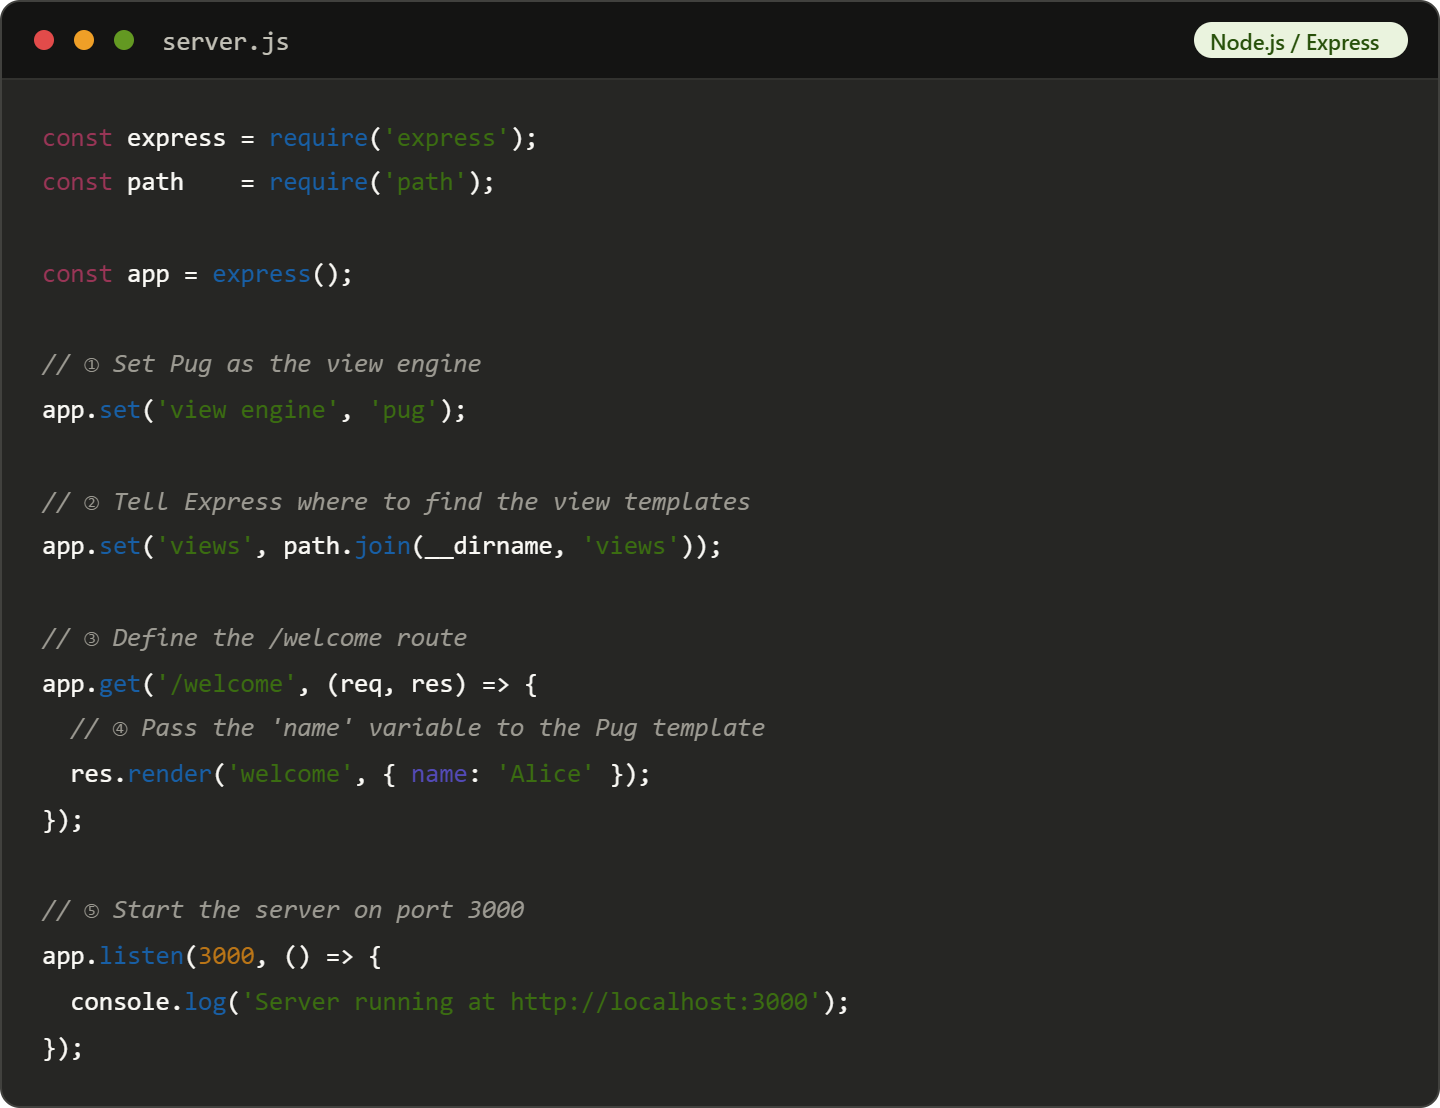



File 2 — views/welcome.pug (the Pug template)
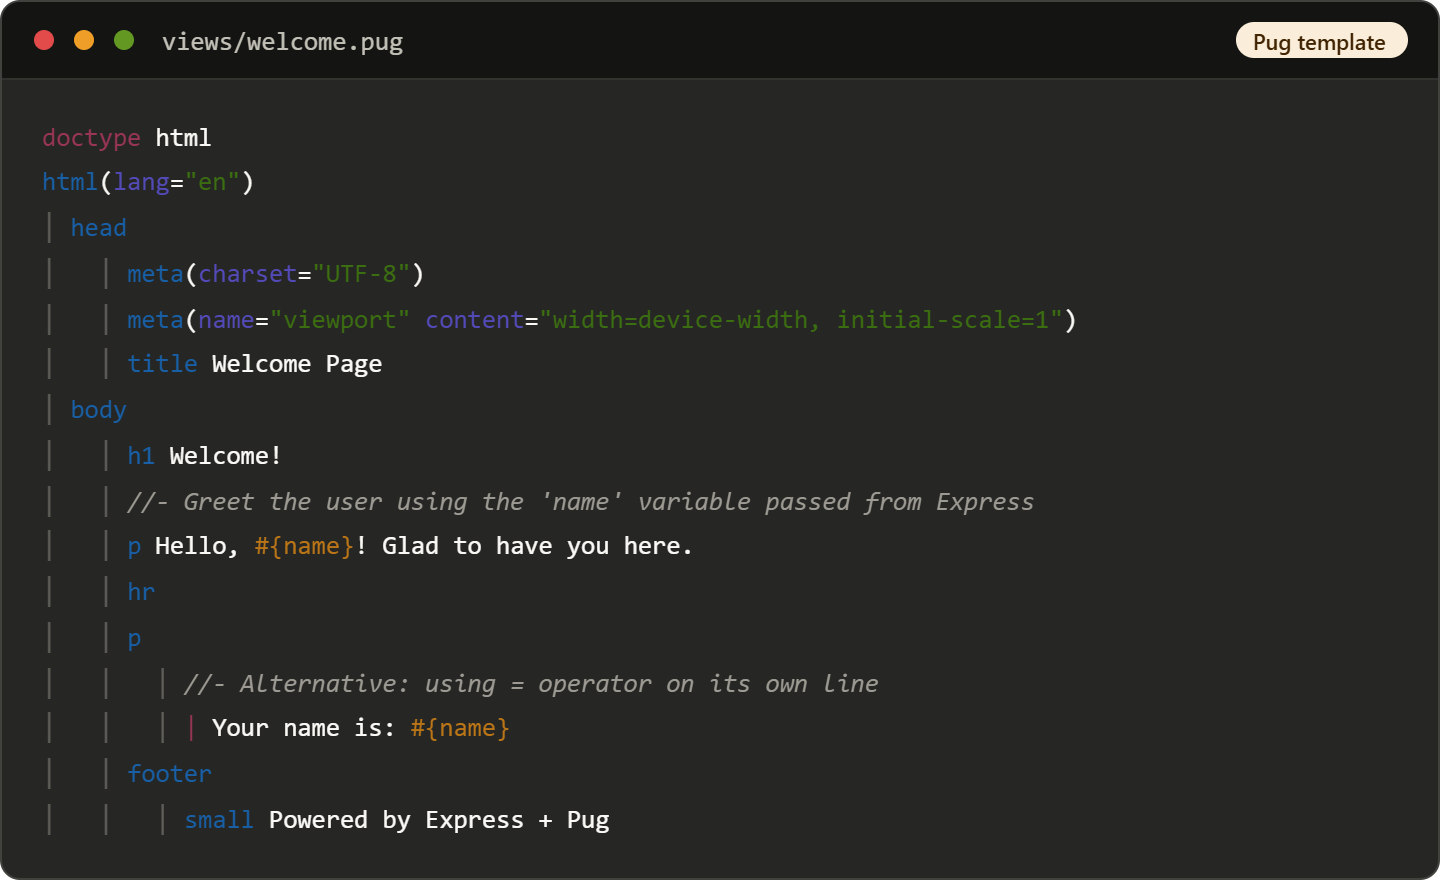

File 3 — HTML output rendered in the browser
This is what Express + Pug produces and sends to the browser when someone visits /welcome:

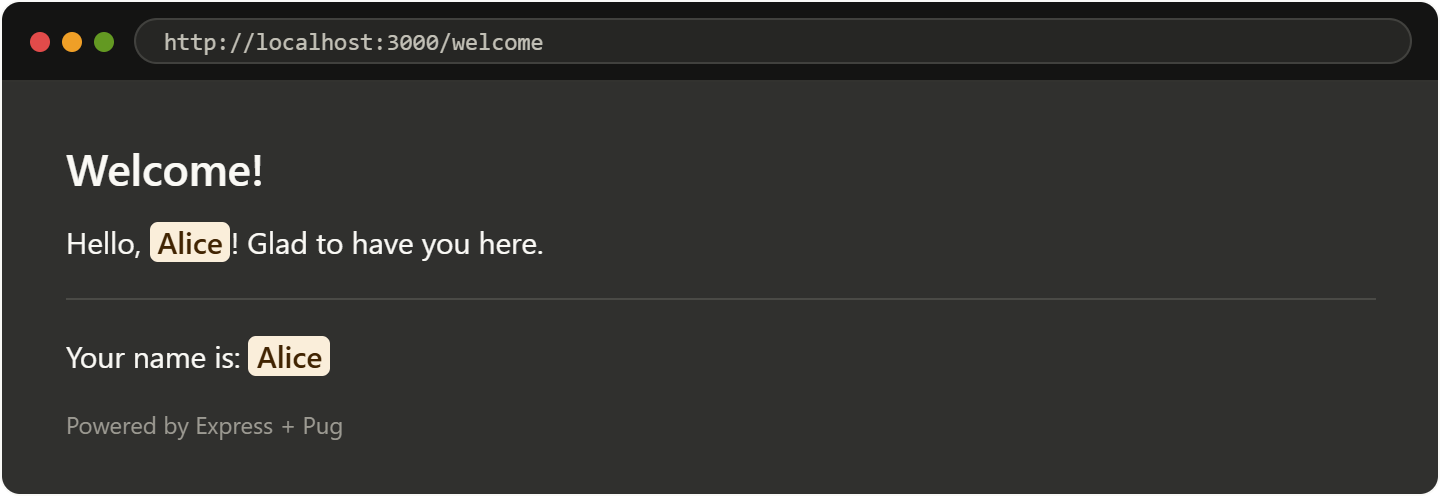

Project structure & setup
Your folder layout should look like this:
<pre>
my-app/
├── server.js
├── package.json
└── views/
    └── welcome.pug
 </pre>

 To install and run the project:
 <pre>
 npm init -y
npm install express pug
node server.js
</pre>
Key concepts explained


app.set('view engine', 'pug') — this single line registers Pug as Express's template engine. Express now knows to compile .pug files instead of sending raw HTML.
app.set('views', path.join(__dirname, 'views')) — tells Express the folder where all templates live. path.join(__dirname, ...) is used instead of a relative string so the path works regardless of which directory you launch the server from.
res.render('welcome', { name: 'Alice' }) — the first argument is the template filename (without the .pug extension). The second argument is a plain JavaScript object — every key in it becomes a variable available inside the template. Here, name: 'Alice' makes name available as #{name} in the Pug file.
#{name} in Pug — this is Pug's interpolation syntax. At compile time, #{name} is replaced with the actual value of the name variable. Pug also HTML-escapes the value automatically, which protects against XSS if the name came from user input.
//- comment — Pug's comment syntax. Unlike // comment (which outputs an HTML comment to the browser), //- is a silent comment — it's stripped out entirely during compilation and never reaches the client.


# Question 3: Explain what a RESTful API is. Then list four HTTP methods (GET, POST, PUT/PATCH, DELETE) and describe what each should do in a REST design for a resource “/tasks”.


Ans 3:

What is a RESTful API?

REST stands for Representational State Transfer. It is an architectural style for designing networked APIs, introduced by Roy Fielding in his 2000 doctoral dissertation. A RESTful API is one that follows REST's six guiding constraints:

Statelessness — every HTTP request from a client must contain all the information needed to process it. The server stores no session state between requests. This makes APIs scalable and easy to cache.

Client–server separation — the client (browser, mobile app) and server (data + logic) are independent. They communicate only through a well-defined interface, so either side can evolve without breaking the other.

Uniform interface — resources are identified by URLs (e.g. /tasks, /tasks/42), and interactions happen through standard HTTP methods. You don't invent custom verbs — you use GET, POST, PUT, PATCH, DELETE, and the method itself signals the intent.

Resource-based — everything is modelled as a resource (a task, a user, an order). Each resource has its own URL. The server returns a representation of that resource (typically JSON), not a page or a procedure.

Layered system & cacheability — responses can be cached, and the architecture can include intermediary layers (load balancers, CDN caches, proxies) without the client knowing.

The combined effect is that a well-designed REST API is predictable, self-descriptive, and usable by any client that speaks HTTP.

The four HTTP methods on /tasks


Here is an interactive reference card for all four methods — click any row to explore further.

  ::view-transition-group(*),

  ::view-transition-old(*),

  ::view-transition-new(*) {
    animation-duration: 0.25s;

    animation-timing-function: cubic-bezier(0.19, 1, 0.22, 1);

  }
VvisualizeVvisualize show_widget

Two key terms worth knowing for an exam: an operation is safe if it doesn't alter server state (only GET qualifies). An operation is idempotent if repeating it produces the same result — GET, PUT, PATCH, and DELETE all qualify, but POST does not, because each POST to /tasks creates a fresh record with a new ID.

# Question 4: Using Express, define routes for a Task resource: GET /tasks, POST /tasks, PUT /tasks/:id, DELETE /tasks/:id. In each handler, just send JSON saying which operation was called (no DB required yet). Write the Express route definitions.


Ans 4: Here is the complete Express route file, broken into two parts — the route definitions with an explanation of each, then an interactive mock terminal showing what each endpoint actually returns.

routes/tasks.js — full route file
<pre>
const express = require('express');
const router  = express.Router();

// ─── GET /tasks ───────────────────────────────────────────────
// Retrieve all tasks. Safe + idempotent — no body needed.
router.get('/', (req, res) => {
  res.json({
    operation: 'GET /tasks',
    message:   'Fetched all tasks',
    data:      [],
  });
});

// ─── GET /tasks/:id ───────────────────────────────────────────
// Retrieve a single task by its ID, read from req.params.
router.get('/:id', (req, res) => {
  const { id } = req.params;
  res.json({
    operation: 'GET /tasks/:id',
    message:   `Fetched task with id ${id}`,
    id:        id,
  });
});

// ─── POST /tasks ──────────────────────────────────────────────
// Create a new task. Client sends JSON body; server assigns ID.
// Requires express.json() middleware to parse req.body.
router.post('/', (req, res) => {
  const body = req.body;
  res.status(201).json({
    operation: 'POST /tasks',
    message:   'Task created',
    received:  body,
  });
});

// ─── PUT /tasks/:id ───────────────────────────────────────────
// Full replacement of an existing task. All fields required.
router.put('/:id', (req, res) => {
  const { id } = req.params;
  const body = req.body;
  res.json({
    operation: 'PUT /tasks/:id',
    message:   `Task ${id} fully replaced`,
    id:        id,
    received:  body,
  });
});

// ─── DELETE /tasks/:id ────────────────────────────────────────
// Remove a task permanently. No request body needed.
// Returns 204 No Content (empty body) — standard REST practice.
router.delete('/:id', (req, res) => {
  const { id } = req.params;
  res.status(204).json({
    operation: 'DELETE /tasks/:id',
    message:   `Task ${id} deleted`,
  });
});

module.exports = router;
</pre>

server.js — wiring the router into Express

<pre>
const express    = require('express');
const taskRoutes = require('./routes/tasks');

const app = express();

// Parse incoming JSON bodies — required for POST and PUT
app.use(express.json()); ① must come before routes

// Mount the task router — all routes inside it are prefixed /tasks
app.use('/tasks', taskRoutes); ② prefix + router

app.listen(3000, () => {
  console.log('Server running on http://localhost:3000');
});
</pre>

Key points explained

express.Router() creates a mini Express app that handles only its own routes. You define routes on router instead of app, then mount the whole router at a prefix (/tasks) in server.js. Every route defined as router.get('/') becomes GET /tasks, and router.get('/:id') becomes GET /tasks/:id — the prefix is added automatically by app.use('/tasks', taskRoutes).


express.json() middleware must be registered before any route that reads req.body. Without it, req.body is undefined on POST and PUT requests — the JSON payload from the client simply isn't parsed.


req.params.id captures the :id wildcard from the URL. When a request hits PUT /tasks/42, Express sets req.params.id to the string "42". You'd convert it to a number with parseInt(id, 10) before querying a real database.


Status codes in res.status(...).json(...) — POST uses 201 Created (not 200), signalling a new resource was made. DELETE uses 204 No Content, which conventionally sends an empty body (though here we still return JSON for illustration; in production you'd call res.sendStatus(204) to send no body at all).


Project structure:
<pre>
my-app/
├── server.js
├── package.json
└── routes/
    └── tasks.js
</pre>

<pre>
npm init -y
npm install express
node server.js

</pre>



# Question 5: Describe in simple words what Passport.js does. Then sketch the flow of user login using local strategy: user submits credentials, server checks them, and if valid, logs in (you can assume a dummy password check). You don’t need to provide full code, just outline key steps (Express + Passport + session or token).


Ans 5:

What is Passport.js?

Think of Passport.js as a bouncer plugin for your Express server. Your server doesn't want to write the logic for checking IDs itself — different apps check different things (username/password, Google account, GitHub OAuth, JWT tokens). Passport provides a single, consistent way to plug in any of these checks, called strategies.

In plain terms: when a login request arrives, Passport intercepts it, hands the credentials to whichever strategy you've configured, waits for a yes/no answer, then either lets the user in or turns them away. Your application code never has to touch the raw credential-checking logic directly — it just says "use this strategy" and responds to the outcome.

The three things Passport always involves are a strategy (the check logic), serializeUser/deserializeUser (how to store and retrieve the user across requests), and session or token storage (so the user doesn't have to log in on every page load).

The local strategy login flow — step by stepHere is a clickable stepper walking through every stage, from the browser form all the way to the protected dashboard. Click "Next step" to advance.

  ::view-transition-group(*),

  ::view-transition-old(*),

  ::view-transition-new(*) {

    animation-duration: 0.25s;

    animation-timing-function: cubic-bezier(0.19, 1, 0.22, 1);

  }
VvisualizeVvisualize show_widget


Sessions vs tokens — a quick comparison


The stepper above shows the session approach (the most common with Passport + Express). But Passport also supports a JWT token approach, which works differently:


With JWT, after the password check succeeds, instead of calling req.login() and creating a session, you call jwt.sign({ id: user.id }, secret) and return the token in the response. On future requests the client sends Authorization: Bearer <token> and Passport's JWT strategy verifies and decodes it — no session store needed at all.


The three things you always configure
No matter which strategy you use, Passport always needs these three pieces wired up:


passport.use(new Strategy(...)) — registers the strategy and its verify callback. You can register multiple strategies on one server (e.g. local + Google + GitHub all at once).


passport.serializeUser / passport.deserializeUser — tells Passport what to put into the session and how to rebuild req.user from it on each request. Only needed for session-based auth; skip for JWT.


passport.initialize() and passport.session() as Express middleware — these must be registered after express-session and before your routes. They attach Passport to every incoming request and handle the cookie-to-user reconstruction automatically.

# Question 6: You want users to log in using their Google account (OAuth) instead of local passwords. What are the high-level steps to implement this with Passport.js and Express? Mention redirection, callback URL, and user data extraction.


Ans 6:

 What changes with Google OAuth vs local passwords?With local login, your server checks the password.

 With Google OAuth, you hand that job entirely to Google. Your app never sees a password — instead, Google issues a temporary authorization code, your server exchanges it for an access token, and Google then hands over a profile (name, email, photo URL) that you use to identify the user.

 The key concept is the callback URL — a route on your own server that Google redirects back to after the user approves access. You register this URL in the Google Cloud Console, and Passport's Google strategy handles the code-exchange and profile-fetch automatically inside that route.

 <pre>
 // app.js
const express = require("express");
const session = require("express-session");
const passport = require("passport");
const GoogleStrategy = require("passport-google-oauth20").Strategy;

const app = express();

// Fake database for example
const users = [];

app.use(
  session({
    secret: "your_session_secret",
    resave: false,
    saveUninitialized: false,
  })
);

app.use(passport.initialize());
app.use(passport.session());

// Save user ID in session
passport.serializeUser((user, done) => {
  done(null, user.id);
});

// Get full user from session ID
passport.deserializeUser((id, done) => {
  const user = users.find((u) => u.id === id);
  done(null, user);
});

// Google OAuth strategy
passport.use(
  new GoogleStrategy(
    {
      clientID: "YOUR_GOOGLE_CLIENT_ID",
      clientSecret: "YOUR_GOOGLE_CLIENT_SECRET",
      callbackURL: "http://localhost:3000/auth/google/callback",
    },
    (accessToken, refreshToken, profile, done) => {
      // Extract user data from Google profile
      let user = users.find((u) => u.googleId === profile.id);

      if (!user) {
        user = {
          id: users.length + 1,
          googleId: profile.id,
          name: profile.displayName,
          email: profile.emails?.[0]?.value,
          photo: profile.photos?.[0]?.value,
        };
        users.push(user);
      }

      return done(null, user);
    }
  )
);

// Home route
app.get("/", (req, res) => {
  res.send(`
    <h2>Home Page</h2>
    <a href="/auth/google">Login with Google</a>
  `);
});

// Step 1: Redirect user to Google login page
app.get(
  "/auth/google",
  passport.authenticate("google", { scope: ["profile", "email"] })
);

// Step 2: Google redirects back to this callback URL
app.get(
  "/auth/google/callback",
  passport.authenticate("google", {
    failureRedirect: "/login",
  }),
  (req, res) => {
    res.redirect("/profile");
  }
);

// Login failed route
app.get("/login", (req, res) => {
  res.send("Login failed");
});

// Protected profile route
app.get("/profile", (req, res) => {
  if (!req.isAuthenticated()) {
    return res.redirect("/");
  }

  res.send(`
    <h2>User Profile</h2>
    <p>Name: ${req.user.name}</p>
    <p>Email: ${req.user.email}</p>
    <img src="${req.user.photo}" width="100" />
    <br><br>
    <a href="/logout">Logout</a>
  `);
});

// Logout route
app.get("/logout", (req, res, next) => {
  req.logout((err) => {
    if (err) return next(err);
    res.redirect("/");
  });
});

app.listen(3000, () => {
  console.log("Server running on http://localhost:3000");
});
</pre>

Install packages


Install these packages before running the app. Passport uses the Google OAuth 2.0 strategy package, and session support is needed to keep the user logged in after authentication.

How it works


/auth/google sends the user to Google’s login page using passport.authenticate(). This is the redirection step.



/auth/google/callback is the callback URL where Google sends the user back after login. Passport verifies the Google response there.



Inside the Google strategy, the profile object contains user data such as profile.id, profile.displayName, profile.emails[0].value, and profile.photos[0].value, which are commonly extracted and stored.




# Question 7 : Explain why we need middleware for security in Express. Write skeleton code showing use of a security middleware (e.g. using helmet), plus custom middleware thatbredirects HTTP to HTTPS (for production).

Ans 7:

Security middleware is needed in Express because it helps protect the app from common web attacks by automatically adding safer HTTP headers and checking requests before they reach your routes. Helmet is a popular example because it can set headers such as Content-Security-Policy, X-Content-Type-Options, and Strict-Transport-Security, which reduce risks like XSS, MIME sniffing, and insecure transport.



Why middleware is needed



Middleware sits between the incoming request and your route handler, so it is the right place to apply security checks globally. This makes security easier to manage because you can protect many routes with one configuration instead of repeating code in every endpoint.



A security middleware like Helmet improves Express security by setting protective HTTP response headers. Helmet is specifically designed as Express middleware and acts as a wrapper around multiple smaller middleware functions that handle these headers.

Skeleton code
<pre>
// app.js
const express = require("express");
const helmet = require("helmet");

const app = express();

// Built-in security middleware
app.use(helmet());

// Custom middleware to redirect HTTP to HTTPS in production
app.use((req, res, next) => {
  if (process.env.NODE_ENV === "production") {
    const proto = req.headers["x-forwarded-proto"] || req.protocol;

    if (proto !== "https") {
      return res.redirect(301, "https://" + req.headers.host + req.url);
    }
  }
  next();
});

app.get("/", (req, res) => {
  res.send("Secure Express app");
});

app.listen(3000, () => {
  console.log("Server running on port 3000");
});
</pre>
How this code works


app.use(helmet()) adds Helmet as a global security middleware, so all responses get safer security headers by default. This is useful because it protects the application at a central point instead of adding header logic manually in every route.



The custom middleware checks whether the app is running in production, then inspects the request protocol. If the request came through HTTP, it sends a 301 redirect to the HTTPS version of the same URL; otherwise it calls next() to continue normal processing.



Exam-style answer
We need middleware for security in Express because middleware can inspect requests and responses before they reach route handlers, making it the best place to apply common protections to the whole app. Helmet is used as security middleware to set important HTTP headers that help defend against attacks such as XSS, MIME sniffing, and insecure communication.

A custom HTTPS-redirect middleware is also useful in production because it forces users onto the secure HTTPS version of the site. The middleware checks the protocol and redirects HTTP requests to HTTPS, while secure requests continue normally.




# Question 8: What is NoSQL injection and why is it a threat in a MongoDB + Express app? Write a small explanation AND describe a safe practice to avoid this risk when accepting user input for queries.


Ans 8:

What is NoSQL Injection?



NoSQL Injection is a type of attack where a hacker manipulates database queries by sending malicious input, especially in NoSQL databases like MongoDB used with Express.js.



Instead of injecting SQL code (like in SQL injection), the attacker injects JSON-based query operators (e.g., $ne, $gt) to change the logic of the query.

Why it is a Threat in MongoDB + Express Apps
Bypasses Authentication


Example: Instead of entering a password, attacker sends:

<pre>
{ "password": { "$ne": null } }
</pre>


- This means “password not equal to null”, which may allow login without knowing the real password.


- Data Leakage
Attackers can retrieve sensitive data by altering query conditions.


- Unauthorized Access
They can manipulate queries to access or modify restricted data.


- Flexible Query Structure
Since MongoDB uses JSON-like queries, it becomes easier to inject operators if input is not validated.



Safe Practice to Avoid NoSQL Injection

1. Validate and Sanitize User Input

Never trust user input. Always ensure it is in the expected format.
<pre>
const username = String(req.body.username);
const password = String(req.body.password);
</pre>

2. Avoid Direct Use of User Input in Queries

❌ Unsafe:
<pre>
User.findOne(req.body);
</pre>

3. Use Libraries to Prevent Injection

Use tools like:

express-mongo-sanitize → removes $ and . from user input
<pre>
const mongoSanitize = require('express-mongo-sanitize');
app.use(mongoSanitize());</pre>


4. Use Schema Validation (Mongoose)

<pre>
const userSchema = new mongoose.Schema({
    username: String,
    password: String
});
</pre>
Conclusion

NoSQL injection is dangerous because it exploits MongoDB’s flexible query format to bypass security. Proper input validation, sanitization, and controlled query structure are essential to prevent such attacks.

Define strict schemas using Mongoose:





# Question 9: Your API serves a frontend hosted on another domain. What is CORS and why do you need to configure it? Show minimal Express code to allow CORS only from https://myfrontend.com.

Ans 9:

 What is CORS?

CORS (Cross-Origin Resource Sharing) is a security feature implemented by browsers that controls how resources on a server can be requested from a different origin (domain, protocol, or port).



For example, if your frontend is hosted on https://myfrontend.com and your backend API is built using Express.js, the browser will block requests unless the server explicitly allows that origin.



Why do we need to configure CORS?

- Enable Cross-Domain Communication
Allows your frontend (different domain) to access your API.
- Prevent Unauthorized Access
By default, browsers block cross-origin requests for security reasons.
- Control Allowed Origins
You can specify which domains are allowed to access your backend.
- Avoid Security Risks
Without proper configuration, your API could be exposed to malicious websites.

Minimal Express Code to Allow CORS for One Domain
1. Install CORS package
<pre>
npm install cors
</pre>
2. Configure CORS in Express
<pre>
const express = require('express');
const cors = require('cors');

const app = express();

// Allow only specific origin
app.use(cors({
    origin: 'https://myfrontend.com'
}));

app.get('/', (req, res) => {
    res.send('CORS configured');
});

app.listen(3000, () => {
    console.log('Server running on port 3000');
});
</pre>
Conclusion


CORS is essential when your frontend and backend are on different domains. It ensures secure communication by allowing only trusted origins to access your API.


#Question 10: Assume after login you store req.user.role as 'user' or 'admin'. Write a middleware requireAdmin that only allows access if role is 'admin', else returns 403. Show how to use it for route DELETE /admin/delete-user/:id.

Ans 10:

 Role-Based Access Control in Express

In Express.js, after login we often store user details like:
<pre>
req.user = { role: 'user' }  // or 'admin'
</pre>


To restrict sensitive operations (like deleting users), we use middleware to check the user’s role.



Middleware: requireAdmin



This middleware allows access only if the user is an admin, otherwise it returns 403 Forbidden.

<pre>
function requireAdmin(req, res, next) {
    if (req.user && req.user.role === 'admin') {
        return next(); // allow access
    }
    return res.status(403).json({ message: 'Forbidden: Admins only' });
}
</pre>
Using the Middleware in a Route



Apply the middleware to protect the route:

<pre>
const express = require('express');
const app = express();

// Example protected route
app.delete('/admin/delete-user/:id', requireAdmin, (req, res) => {
    const userId = req.params.id;

    // Logic to delete user (dummy example)
    res.send(`User with ID ${userId} deleted`);
});
</pre>

Explanation

- Middleware runs before the route handler
- If role = 'admin' → request proceeds
- If not → response ends with 403 error
- Ensures only authorized users can perform critical actions


Conclusion

Using middleware like requireAdmin is an effective way to implement role-based access control and secure sensitive routes in Express applications.